# **IV. Exploratory Data Analysis**

The raw data collection will undergo exploratory data analysis to further understand the data, and to be able to identify what could be done to clean the dataset in the later step data preprocessing.


In [122]:
%pip install praw numpy nltk pandas wordcloud matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [123]:
import pandas as pd
import numpy as np
import pandas as pd

In [124]:
# Instatiate NLTK module
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

stopwords = stopwords.words('english')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Uwie\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Uwie\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Uwie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [125]:
# Set up visualization configurations
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.style as style

# style.use('fivethirtyeight')
sns.set_theme(rc={'figure.figsize': (12, 6)})

In [126]:
reddit_eda = pd.read_csv("../Binwag - PhilippineRedditAgricultureAnalysis/data/reddit_data.csv")

print("Shape:", reddit_eda.shape)   # rows x columns
print("\nColumns:", reddit_eda.columns.tolist())
reddit_eda.tail()


Shape: (13171, 9)

Columns: ['post_title', 'post_url', 'comment', 'comment_author', 'comment_score', 'post_body', 'post_score', 'post_author', 'created_utc']


,post_title,post_url,comment,comment_author,comment_score,post_body,post_score,post_author,created_utc
13166,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,That’s why fuck the Dutertes,nikolodeon,10.0,NaN,NaN,NaN,2024-05-03 11:30:11
13167,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,Fr? That's scary.,[deleted],2.0,NaN,NaN,NaN,2024-05-03 12:32:41
13168,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,This partnership is very daijoubu,IkigaiSagasu,5.0,NaN,NaN,NaN,2024-05-03 10:33:52
13169,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,"Yeah, there’s a huge connection between corrup...",FilipinxFurry,1.0,NaN,NaN,NaN,2024-05-03 12:36:12
13170,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,"Yup ganyan din ginagawa ng Russia, kaya mas pi...",SuperBombaBoy,1.0,NaN,NaN,NaN,2024-05-03 16:57:35


In [127]:
reddit_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13171 entries, 0 to 13170
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   post_title      13171 non-null  object 
 1   post_url        13171 non-null  object 
 2   comment         12944 non-null  object 
 3   comment_author  12944 non-null  object 
 4   comment_score   12944 non-null  float64
 5   post_body       227 non-null    object 
 6   post_score      227 non-null    float64
 7   post_author     227 non-null    object 
 8   created_utc     13171 non-null  object 
dtypes: float64(2), object(7)
memory usage: 926.2+ KB


In [128]:
def clean_text(df):
    # Ensure comment and post_title are strings (replace NaN with empty string)
    df['comment'] = df['comment'].fillna("").astype(str)
    df['post_title'] = df['post_title'].fillna("").astype(str)

    # Lowercase
    df['cleaned_comment'] = df['comment'].str.lower()
    df['cleaned_post_title'] = df['post_title'].str.lower()

    # Remove usernames, non-alphanumeric characters, and links
    regex_pattern = r'(@[A-Za-z0-9_]+)|([^A-Za-z0-9_ \t])|(\w+:\/\/\S+)'
    df['cleaned_comment'] = df['cleaned_comment'].str.replace(regex_pattern, '', regex=True)
    df['cleaned_post_title'] = df['cleaned_post_title'].str.replace(regex_pattern, '', regex=True)

    # Remove stopwords
    df['cleaned_comment'] = df['cleaned_comment'].apply(
        lambda row: ' '.join([word for word in row.split() if word not in stopwords]))
    df['cleaned_post_title'] = df['cleaned_post_title'].apply(
        lambda row: ' '.join([word for word in row.split() if word not in stopwords]))

    # Lemmatization (verbs → adjectives → nouns)
    for pos in ['v', 'a', 'n']:
        df['cleaned_comment'] = df['cleaned_comment'].apply(
            lambda row: ' '.join([lemmatizer.lemmatize(x, pos) for x in row.split()]))
        df['cleaned_post_title'] = df['cleaned_post_title'].apply(
            lambda row: ' '.join([lemmatizer.lemmatize(x, pos) for x in row.split()]))

    # Strip whitespace
    df['cleaned_comment'] = df['cleaned_comment'].str.strip()
    df['cleaned_post_title'] = df['cleaned_post_title'].str.strip()

    return df


In [129]:
reddit_cleaned = clean_text(reddit_eda)
reddit_cleaned.head()

,post_title,post_url,comment,comment_author,comment_score,post_body,post_score,post_author,created_utc,cleaned_comment,cleaned_post_title
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,,NaN,NaN,"Oh God, Marcos Camp is in danger of opening a ...",869.0,bigbyte2024,2025-07-07 11:40:47,,sen marcoleta hold blue ribbon committee sen b...
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,"Buti naman si Kiko papalit sa Agriculture, dam...",Numerous-Tree-902,421.0,NaN,NaN,NaN,2025-07-07 12:38:47,buti naman si kiko papalit sa agriculture dam ...,sen marcoleta hold blue ribbon committee sen b...
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,May sumpa rin ang blue ribbon. \n\nTolentino -...,extraricekillings,135.0,NaN,NaN,NaN,2025-07-07 12:21:50,may sumpa rin ang blue ribbon tolentino talogo...,sen marcoleta hold blue ribbon committee sen b...
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,Bobo naman bakit sa kanya Blue Ribbon Committee,Karmas_Classroom,81.0,NaN,NaN,NaN,2025-07-07 11:51:43,bobo naman bakit sa kanya blue ribbon committee,sen marcoleta hold blue ribbon committee sen b...
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",https://reddit.com/r/Philippines/comments/1ltr...,Blue Ribbon Committee is a curse seat lol yeah...,LigmaV,39.0,NaN,NaN,NaN,2025-07-07 12:46:06,blue ribbon committee curse seat lol yeah maga...,sen marcoleta hold blue ribbon committee sen b...


In [130]:
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Combine comments + posts
reddit_cleaned["cleaned_text"] = reddit_cleaned["cleaned_post_title"] + " " + reddit_cleaned["cleaned_comment"]

# Tokenize & count words
vectorizer = CountVectorizer(stop_words='english')  # you can extend with Tagalog stopwords
X = vectorizer.fit_transform(reddit_cleaned["cleaned_text"])
word_counts = X.toarray().sum(axis=0)

# Create DataFrame of word frequencies
words_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": word_counts
}).sort_values(by="count", ascending=False)

print(words_freq.head(20))  # top 20 words


               word  count
23162            sa   8430
16222            na   8233
18107            ng   6352
1647            ang   5378
20468    philippine   4132
1255    agriculture   3976
15615           mga   3720
28543          yung   2777
19143            pa   2549
12657          lang   2387
22893          rice   1807
7555         farmer   1710
12268            ko   1673
15884            mo   1542
1247   agricultural   1423
17444         naman   1403
2321             ba   1360
9485          hindi   1251
18185          nila   1239
20385          pero   1214


In [131]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

added_stopwords = [
    "sa", "na", "ng", "ang", "mga", "yung", "pa", "lang", "naman", "ba",
    "ko", "mo", "nila", "pero", "daw", "din", "rin", "kasi", "nga", "eh",
    "si", "ni", "kay", "para", "kung", "ay", "lahat", "wala", "may", "meron",
    "dapat", "talaga", "ano", "oo", "hindi", "diba", "sobrang", "super",
    "mas", "isa", "dalawa", "tatlo", "sen", "say", "ma", "make", "ako", "ka"
]

custom_stopwords = list(set(ENGLISH_STOP_WORDS).union(added_stopwords))

In [132]:
vectorizer = CountVectorizer(stop_words=custom_stopwords)
X = vectorizer.fit_transform(reddit_cleaned["cleaned_text"])

word_counts = X.toarray().sum(axis=0)

words_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": word_counts
}).sort_values(by="count", ascending=False)

print(words_freq.head(20))


               word  count
20433    philippine   4132
1255    agriculture   3976
22858          rice   1807
7544         farmer   1710
1247   agricultural   1423
28180          work   1190
24046          sila   1116
28328           yan   1110
12978          like   1099
5875             di   1075
21656    profession   1069
5109        country   1015
23585     secretary   1008
12591          land    928
12242          know    912
4642      committee    888
20296        people    876
25899         thats    861
15004        marcos    853
6337           dont    853


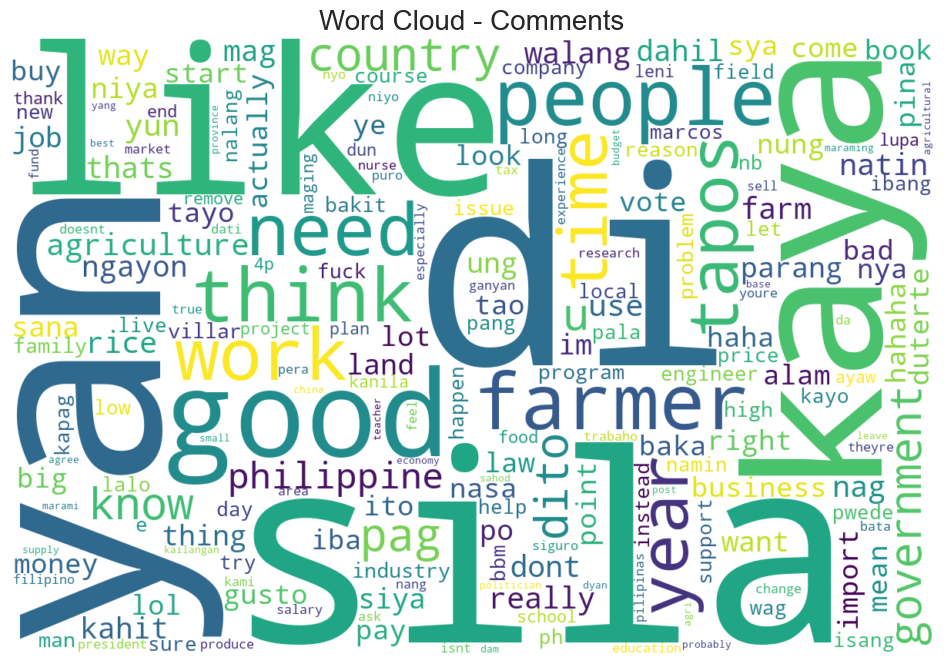

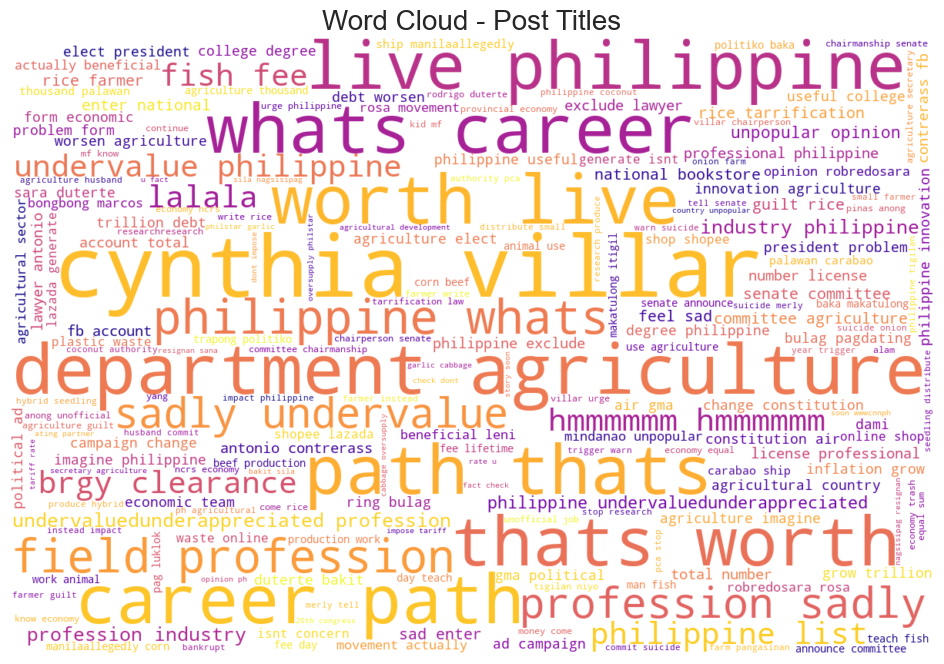

In [133]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Fill NAs just in case
reddit_cleaned['cleaned_post_title'] = reddit_cleaned['cleaned_post_title'].fillna("")
reddit_cleaned['cleaned_comment'] = reddit_cleaned['cleaned_comment'].fillna("")

# Join all comments
all_comments = " ".join(reddit_cleaned['cleaned_comment'].tolist())

# Join all post titles
all_titles = " ".join(reddit_cleaned['cleaned_post_title'].tolist())

# WordCloud for Comments
wordcloud_comments = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="viridis"
).generate(all_comments)

plt.figure(figsize=(12, 8))
plt.title("Word Cloud - Comments", fontsize=20)
plt.imshow(wordcloud_comments, interpolation="bilinear")
plt.axis("off")
plt.show()

# WordCloud for Post Titles
wordcloud_titles = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="plasma"  # try a different colormap for variety
).generate(all_titles)

plt.figure(figsize=(12, 8))
plt.title("Word Cloud - Post Titles", fontsize=20)
plt.imshow(wordcloud_titles, interpolation="bilinear")
plt.axis("off")
plt.show()


In [134]:
# Drop unnecessary columns
reddit_cleaned = reddit_cleaned.drop(
    ["comment_score", "comment_author", "post_url", "post_score", "post_body", "post_author",], 
    axis=1
)

# Export to CSV
output_path = "../Binwag - PhilippineRedditAgricultureAnalysis/data/reddit_cleaned.csv"
reddit_cleaned.to_csv(output_path, index=False, encoding="utf-8")

print(f"Cleaned dataset saved to {output_path}")

reddit_cleaned.tail()


Cleaned dataset saved to ../Binwag - PhilippineRedditAgricultureAnalysis/data/reddit_cleaned.csv


,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text
13166,"Philippines, Japan deepen ties with $1.5 billi...",That’s why fuck the Dutertes,2024-05-03 11:30:11,thats fuck dutertes,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...
13167,"Philippines, Japan deepen ties with $1.5 billi...",Fr? That's scary.,2024-05-03 12:32:41,fr thats scary,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...
13168,"Philippines, Japan deepen ties with $1.5 billi...",This partnership is very daijoubu,2024-05-03 10:33:52,partnership daijoubu,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...
13169,"Philippines, Japan deepen ties with $1.5 billi...","Yeah, there’s a huge connection between corrup...",2024-05-03 12:36:12,yeah there huge connection corrupt countriesth...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...
13170,"Philippines, Japan deepen ties with $1.5 billi...","Yup ganyan din ginagawa ng Russia, kaya mas pi...",2024-05-03 16:57:35,yup ganyan din ginagawa ng russia kaya ma pini...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...


# **Topic Modelling**

This section of this notebook

In [135]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# --- Use cleaned post titles ---
df = reddit_cleaned.copy()
df = df[df["cleaned_post_title"].notna()]  # drop rows with null titles

# Vectorize using cleaned titles
vectorizer = CountVectorizer(stop_words=custom_stopwords, max_df=0.9, min_df=5)
dtm = vectorizer.fit_transform(df["cleaned_post_title"])

# Fit LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # adjust topic count
lda.fit(dtm)

# Display topics
def display_topics(model, feature_names, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(f"Topic {topic_idx+1}: {' | '.join(top_words)}")

display_topics(lda, vectorizer.get_feature_names_out(), 10)

# Assign most probable topic to each title
topic_results = lda.transform(dtm)
df["Dominant_Topic"] = topic_results.argmax(axis=1) + 1

# Save results
output_path = "../Binwag - PhilippineRedditAgricultureAnalysis/data/reddit_title_topics.csv"
df.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved topic-labeled titles to {output_path}")


Topic 1: philippine | agriculture | secretary | agricultural | industry | undervaluedunderappreciated | profession | number | account | license
Topic 2: philippine | agriculture | rice | farmer | field | list | profession | undervalue | sadly | national
Topic 3: economy | fish | hmmmmmm | clearance | lalala | brgy | fee | agricultural | day | philippine
Topic 4: agriculture | duterte | president | department | committee | senate | suicide | problem | onion | economic
Topic 5: philippine | whats | worth | career | thats | path | live | mindanao | opinion | unpopular
Saved topic-labeled titles to ../Binwag - PhilippineRedditAgricultureAnalysis/data/reddit_title_topics.csv


## **Topic Modelling Findings**

From what I understood, initially each topics can be classified as the following:

|Topic Number   | Interpretation      |
|-------------  |---------------------|
|Topic 1        | Agriculture is generally undervalued as a profession | 
|Topic 2        | National concern on rice farming and agriculture related issues | 
|Topic 3        | Local / Barangay-level agricultural concerns / probably fisheries or general-agriculture | 
|Topic 4        | Issues on agriculture-based politics | 
|Topic 5        | Perspectives and opinions on agriculture | 

In [139]:
%pip install pyLDAvis

  Using cached pyLDAvis-3.4.1-py3-none-any.whl.metadata (4.2 kB)
  Using cached funcy-2.0-py2.py3-none-any.whl.metadata (5.9 kB)
Using cached pyLDAvis-3.4.1-py3-none-any.whl (2.6 MB)
Using cached funcy-2.0-py2.py3-none-any.whl (30 kB)

   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvis]
   -------------------- ------------------- 1/2 [pyLDAvi

In [140]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import numpy as np

In [141]:
reddit_cleaned.tail()

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text
13166,"Philippines, Japan deepen ties with $1.5 billi...",That’s why fuck the Dutertes,2024-05-03 11:30:11,thats fuck dutertes,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...
13167,"Philippines, Japan deepen ties with $1.5 billi...",Fr? That's scary.,2024-05-03 12:32:41,fr thats scary,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...
13168,"Philippines, Japan deepen ties with $1.5 billi...",This partnership is very daijoubu,2024-05-03 10:33:52,partnership daijoubu,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...
13169,"Philippines, Japan deepen ties with $1.5 billi...","Yeah, there’s a huge connection between corrup...",2024-05-03 12:36:12,yeah there huge connection corrupt countriesth...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...
13170,"Philippines, Japan deepen ties with $1.5 billi...","Yup ganyan din ginagawa ng Russia, kaya mas pi...",2024-05-03 16:57:35,yup ganyan din ginagawa ng russia kaya ma pini...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...


In [142]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
doc_term_matrix = vectorizer.fit_transform(reddit_cleaned['cleaned_text'])

In [143]:
doc_term_matrix.toarray().shape

(13171, 11427)

In [145]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=3, random_state=42)

In [146]:
len(LDA.components_)

3

In [147]:
topic_term_matrix = LDA.components_
topic_term_matrix

array([[1.59670578, 4.32093545, 0.34040043, ..., 0.3426229 , 0.33552382,
        1.61301609],
       [0.33343495, 0.34564724, 2.2853995 , ..., 5.68031986, 1.33954229,
        6.03829717],
       [1.06985927, 0.33341731, 0.37420007, ..., 1.97705724, 1.32493389,
        0.34868674]])

In [148]:
topic1 = topic_term_matrix[0]
topic1

array([1.59670578, 4.32093545, 0.34040043, ..., 0.3426229 , 0.33552382,
       1.61301609])

In [149]:
topic1.argsort()

array([ 872,  251, 1815, ..., 6620, 7210, 9173], dtype=int64)

In [150]:
topic1_top_idx = topic1.argsort()[-15:]
topic1_top_idx

array([10881,  9199,  5474,  8051,  6155,  2432,  3290,  6496,  5305,
        6401,   443,   610,  6620,  7210,  9173], dtype=int64)

In [151]:
topic1_top = [vectorizer.get_feature_names_out()[idx] for idx in topic1_top_idx]
topic1_top

['undervalue',
 'sadly',
 'list',
 'philippine',
 'marcos',
 'department',
 'field',
 'mo',
 'lang',
 'mga',
 'agriculture',
 'ang',
 'na',
 'ng',
 'sa']

In [152]:
for index, topic in enumerate(LDA.components_):
  print(f'The top 15 words for topic #{index}')
  print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-15:]])
  print('\n')

The top 15 words for topic #0
['undervalue', 'sadly', 'list', 'philippine', 'marcos', 'department', 'field', 'mo', 'lang', 'mga', 'agriculture', 'ang', 'na', 'ng', 'sa']


The top 15 words for topic #1
['say', 'farm', 'problem', 'people', 'make', 'thats', 'like', 'work', 'land', 'country', 'agricultural', 'farmer', 'rice', 'agriculture', 'philippine']


The top 15 words for topic #2
['pero', 'hindi', 'sila', 'philippine', 'nila', 'ba', 'ko', 'lang', 'yung', 'pa', 'mga', 'ang', 'ng', 'sa', 'na']




In [153]:
doc_topic_matrix = LDA.transform(doc_term_matrix)
doc_topic_matrix

array([[0.94567988, 0.02834347, 0.02597665],
       [0.86623336, 0.11949041, 0.01427623],
       [0.9643205 , 0.01771754, 0.01796196],
       ...,
       [0.03386828, 0.93242778, 0.03370395],
       [0.01490542, 0.9697975 , 0.01529708],
       [0.00727041, 0.26151697, 0.73121262]])

In [154]:
reddit_cleaned['Topic'] = doc_topic_matrix.argmax(axis=1)
reddit_cleaned

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Topic
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",,2025-07-07 11:40:47,,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...","Buti naman si Kiko papalit sa Agriculture, dam...",2025-07-07 12:38:47,buti naman si kiko papalit sa agriculture dam ...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",May sumpa rin ang blue ribbon. \n\nTolentino -...,2025-07-07 12:21:50,may sumpa rin ang blue ribbon tolentino talogo...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Bobo naman bakit sa kanya Blue Ribbon Committee,2025-07-07 11:51:43,bobo naman bakit sa kanya blue ribbon committee,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Blue Ribbon Committee is a curse seat lol yeah...,2025-07-07 12:46:06,blue ribbon committee curse seat lol yeah maga...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
...,...,...,...,...,...,...,...
13166,"Philippines, Japan deepen ties with $1.5 billi...",That’s why fuck the Dutertes,2024-05-03 11:30:11,thats fuck dutertes,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13167,"Philippines, Japan deepen ties with $1.5 billi...",Fr? That's scary.,2024-05-03 12:32:41,fr thats scary,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13168,"Philippines, Japan deepen ties with $1.5 billi...",This partnership is very daijoubu,2024-05-03 10:33:52,partnership daijoubu,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13169,"Philippines, Japan deepen ties with $1.5 billi...","Yeah, there’s a huge connection between corrup...",2024-05-03 12:36:12,yeah there huge connection corrupt countriesth...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1


In [155]:
doc_topic_matrix = LDA.transform(doc_term_matrix)
doc_topic_matrix

array([[0.94567988, 0.02834347, 0.02597665],
       [0.86623336, 0.11949041, 0.01427623],
       [0.9643205 , 0.01771754, 0.01796196],
       ...,
       [0.03386828, 0.93242778, 0.03370395],
       [0.01490542, 0.9697975 , 0.01529708],
       [0.00727041, 0.26151697, 0.73121262]])

In [156]:
reddit_cleaned['Topic'] = doc_topic_matrix.argmax(axis=1)
reddit_cleaned

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Topic
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",,2025-07-07 11:40:47,,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...","Buti naman si Kiko papalit sa Agriculture, dam...",2025-07-07 12:38:47,buti naman si kiko papalit sa agriculture dam ...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",May sumpa rin ang blue ribbon. \n\nTolentino -...,2025-07-07 12:21:50,may sumpa rin ang blue ribbon tolentino talogo...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Bobo naman bakit sa kanya Blue Ribbon Committee,2025-07-07 11:51:43,bobo naman bakit sa kanya blue ribbon committee,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Blue Ribbon Committee is a curse seat lol yeah...,2025-07-07 12:46:06,blue ribbon committee curse seat lol yeah maga...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,0
...,...,...,...,...,...,...,...
13166,"Philippines, Japan deepen ties with $1.5 billi...",That’s why fuck the Dutertes,2024-05-03 11:30:11,thats fuck dutertes,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13167,"Philippines, Japan deepen ties with $1.5 billi...",Fr? That's scary.,2024-05-03 12:32:41,fr thats scary,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13168,"Philippines, Japan deepen ties with $1.5 billi...",This partnership is very daijoubu,2024-05-03 10:33:52,partnership daijoubu,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13169,"Philippines, Japan deepen ties with $1.5 billi...","Yeah, there’s a huge connection between corrup...",2024-05-03 12:36:12,yeah there huge connection corrupt countriesth...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1


In [160]:
reddit_cleaned.loc[:, ['post_title', 'Topic']].to_excel('categorized_airline_tweets.xlsx')

In [161]:
vocab = vectorizer.get_feature_names_out()
doc_lengths = [len(doc) for doc in reddit_cleaned['cleaned_text']]
term_freqs = doc_term_matrix.sum(axis=0)
term_freqs = np.array(term_freqs).flatten()
vis_data = pyLDAvis.prepare(topic_term_matrix, doc_topic_matrix, doc_lengths, vocab, term_freqs)

pyLDAvis.display(vis_data)

In [162]:
reddit_title_topics = pd.read_csv("../Binwag - PhilippineRedditAgricultureAnalysis/data/reddit_title_topics.csv")
reddit_title_topics.tail()

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Dominant_Topic
13166,"Philippines, Japan deepen ties with $1.5 billi...",That’s why fuck the Dutertes,2024-05-03 11:30:11,thats fuck dutertes,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13167,"Philippines, Japan deepen ties with $1.5 billi...",Fr? That's scary.,2024-05-03 12:32:41,fr thats scary,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13168,"Philippines, Japan deepen ties with $1.5 billi...",This partnership is very daijoubu,2024-05-03 10:33:52,partnership daijoubu,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13169,"Philippines, Japan deepen ties with $1.5 billi...","Yeah, there’s a huge connection between corrup...",2024-05-03 12:36:12,yeah there huge connection corrupt countriesth...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
13170,"Philippines, Japan deepen ties with $1.5 billi...","Yup ganyan din ginagawa ng Russia, kaya mas pi...",2024-05-03 16:57:35,yup ganyan din ginagawa ng russia kaya ma pini...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1
